## Exploring temporal biases in km-scale models

In [2]:
import os
import numpy as np

import autoroot

import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec

from src.analysis import bootstrap_symmetric_kl
from notebooks.utils.patch_likelihoods import load_all_dataset_likelihoods
from notebooks.utils.plots import IFS_COLOR, ICON_COLOR, GOES_COLOR

In [3]:
datasets = ["goes_train", "goes_test", "ifs_train", "ifs_test", "icon_train", "icon_test"]
likelihood_dir_64x64 = os.environ.get('RESULTS_DIR_64x64')
all_dataset_likelihoods = load_all_dataset_likelihoods(likelihood_dir_64x64, datasets, add_land_ocean=True, add_local_solar_time=True)

In [4]:
# Initialize arrays
kl_goes_icon_lst = np.zeros(24)
kl_goes_icon_std = np.zeros(24)
kl_goes_ifs_lst  = np.zeros(24)
kl_goes_ifs_std  = np.zeros(24)

plot_keys = ["goes", "icon", "ifs"]

# Compute KL divergence and bootstrapped variance for each hour
for h in range(24):
    subsets = {}
    for key in plot_keys:
        df = all_dataset_likelihoods[key]
        subset = df[df['hour_LST'] == h]['likelihood'].values
        subsets[key] = subset

    # ICON vs GOES
    if len(subsets["goes"]) > 0 and len(subsets["icon"]) > 0:
        kl_mean, kl_std, _, _ = bootstrap_symmetric_kl(subsets["goes"], subsets["icon"], bins=100, n_bootstrap=500, random_state=42)
        kl_goes_icon_lst[h] = kl_mean
        kl_goes_icon_std[h] = kl_std
    else:
        kl_goes_icon_lst[h] = np.nan
        kl_goes_icon_std[h] = np.nan

    # IFS vs GOES
    if len(subsets["goes"]) > 0 and len(subsets["ifs"]) > 0:
        kl_mean, kl_std, _, _ = bootstrap_symmetric_kl(subsets["goes"], subsets["ifs"], bins=100, n_bootstrap=500, random_state=42)
        kl_goes_ifs_lst[h] = kl_mean
        kl_goes_ifs_std[h] = kl_std
    else:
        kl_goes_ifs_lst[h] = np.nan
        kl_goes_ifs_std[h] = np.nan

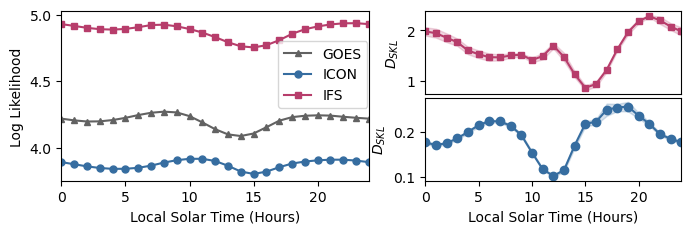

In [5]:
# left big panel + two right-side panels stacked
fig = plt.figure(figsize=(8, 2.2))  # slightly taller to fit two right panels nicely
gs = GridSpec(nrows=2, ncols=2, figure=fig, width_ratios=[3, 2.5], height_ratios=[1, 1])

# left panel (spans both rows): mean likelihood vs LST
ax_left = fig.add_subplot(gs[:, 0])

# right panels
ax_right_top = fig.add_subplot(gs[0, 1])    # IFS vs GOES
ax_right_bottom = fig.add_subplot(gs[1, 1]) # ICON vs GOES

# right panels: KL divergence plots
hours = list(range(25))  # wrap-around for cyclic plot

# IFS vs GOES (TOP)
ax_right_top.plot(
    hours,
    kl_goes_ifs_lst.tolist() + [kl_goes_ifs_lst[0]],
    markersize=5, color=IFS_COLOR, marker='s', label='IFS vs GOES'
)
ax_right_top.fill_between(
    hours,
    (kl_goes_ifs_lst - kl_goes_ifs_std).tolist() + [kl_goes_ifs_lst[0]-kl_goes_ifs_std[0]],
    (kl_goes_ifs_lst + kl_goes_ifs_std).tolist() + [kl_goes_ifs_lst[0]+kl_goes_ifs_std[0]],
    color=IFS_COLOR, alpha=0.2
)
ax_right_top.set_ylabel(r'$D_{SKL}$')
ax_right_top.set_xlim(0, 24)
ax_right_top.set_xticks([])

# top panel: no x-label to reduce clutter
# ICON vs GOES (BOTTOM)
ax_right_bottom.plot(
    hours,
    kl_goes_icon_lst.tolist() + [kl_goes_icon_lst[0]],
    color=ICON_COLOR, marker='o', label='ICON vs GOES'
)
ax_right_bottom.fill_between(
    hours,
    (kl_goes_icon_lst - kl_goes_icon_std).tolist() + [kl_goes_icon_lst[0]-kl_goes_icon_std[0]],
    (kl_goes_icon_lst + kl_goes_icon_std).tolist() + [kl_goes_icon_lst[0]+kl_goes_icon_std[0]],
    color=ICON_COLOR, alpha=0.2
)
ax_right_bottom.set_ylabel(r'$D_{SKL}$')
ax_right_bottom.set_xlim(0, 24)
ax_right_bottom.set_xticks(range(0, 25, 5))
ax_right_bottom.set_xlabel('Local Solar Time (Hours)')
ax_right_bottom.set_yticks([0.1, 0.2])
# left panel: mean likelihood vs local solar time
hours = list(range(25))  # wrap-around for cyclic plot

def bootstrap_mean(data, n_boot=500):
    means = []
    n = len(data)
    for _ in range(n_boot):
        sample = np.random.choice(data, size=n, replace=True)
        means.append(np.mean(sample))
    return np.mean(means), np.std(means)

for key, color in zip(['goes', 'icon', 'ifs'], [GOES_COLOR, ICON_COLOR, IFS_COLOR]):
    mean_lkl = []
    for h in range(24):
        df = all_dataset_likelihoods[key]
        subset = df[df['hour_LST'] == h]['likelihood']
        mean_lkl.append(np.mean(subset) / (64*64))

    ax_left.plot(
        hours,
        mean_lkl + [mean_lkl[0]],
        label=key.upper(),
        color=color,
        markersize=5,
        marker='^' if key == 'goes' else 's' if key == 'ifs' else 'o'
    )

ax_left.set_yticks([np.round(n, 2) for n in np.arange(4, 5.1, 0.5)])
ax_left.set_ylim(3.75, 5.025)
ax_left.set_xlim(0, 24)
ax_left.set_xlabel('Local Solar Time (Hours)')
ax_left.set_ylabel('Log Likelihood')
ax_left.legend(bbox_to_anchor=(0.85, 0.865), loc="upper center")

plt.subplots_adjust(wspace=0.2, hspace=0.05)
plt.show()